## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [1]:
import os
print("Directorio actual:", os.getcwd())
print("Archivos disponibles:", os.listdir('.'))

Directorio actual: /app
Archivos disponibles: ['S5 ladb_mobility_economy_project_student.ipynb', '.ipynb_checkpoints', 'ladb_mobility_economy_2024_clean.csv']


In [2]:
# importar librerías
import pandas as pd
import numpy as n


In [3]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')#completa el código

In [4]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [5]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [6]:
# Examinar la estructura de traffic

traffic.info()
traffic.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo ... object
  -deberian cambiarse a numericas
  

In [7]:
# Examinar la estructura de eco
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`,`PM2.5 (μg/m³)`,`Population (M)`
- son tipo object deberian cambiarse a numericas


### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [8]:
# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic.columns=('country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live','jams_length_kms', 'jams_count', 'traffic_index_week_ago','update_time_utc_week_ago', 'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins', 'mins_delay')
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [9]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco.columns=('year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m')
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [10]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc']) #tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago']) #tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [11]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('.', '').str.replace(',', '.').str.replace('%', '').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace('.', '').str.replace(',', '.').str.replace('%', '').astype(float)


# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,62.0,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,91.0,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,98.0,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [12]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic["update_time_utc"].dt.year 

# Verificar cambio
#traffic["year"].isin(["2024"])
traffic.head()

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238,2025
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016,2025


In [13]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic["year"].isin([2024])].copy()
eco_2024 = eco[eco["year"].isin([2024])].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())

display(eco_2024.head())


# Para ver los primeros 3 registros de 2024:
#traffic_2024.head(3)
#print("Años en traffic:", traffic["year"].unique())
#print("Años en eco:", eco["year"].unique())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,72.0,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,85.0,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,92.0,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,78.0,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,124.0,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [14]:

# Calcular los  promedios de trafico por ciudad, país y año
#traffic_2024.head()
traffic_city_year_2024 = traffic_2024.groupby(["city","country","year"]).agg("mean").reset_index()  # tu código aqui

# Mostrar resultado
traffic_city_year_2024.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,15.821025,16.267977,15.493804,0.774172
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,21.874836,13.397861,12.604894,0.792968
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,17.445227,15.219292,14.724016,0.495276
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,14.295209,9.829092,9.689328,0.139764
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,22.508810,15.879694,14.749945,1.129749


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [15]:
# tu código aquí
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,36.443813,21.809092,19.953550,1.855542
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,37.441779,22.443778,21.745626,0.698152
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,29.337407,18.505043,17.108691,1.396351
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,30.827376,17.714139,16.388979,1.325160
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,68.628341,27.134629,24.664734,2.469894
...,...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,15.975631,16.226009,15.592715,0.633294
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,14.470460,15.746717,15.244916,0.501802
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,10.938767,11.662590,11.467639,0.194951
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,6.666082,9.467150,9.484694,-0.017544


La ciudad con el mayor tiempo promedio de tráfico es ...


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [16]:

# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

#traffic_2024.columns
#eco_2024.columns
# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,how="inner",on=["city","year"])# tu código aquí

# Mostrar las primeras 5 filas
# tu código aquí
merged.head(5)




,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,buenos-aires,ARG,2024,138.3,11.0,44.6,43.0,-0.248936,16.569802,16.818738,18117.0,72.0,"14,50",15400000.0
1,buenos-aires,ARG,2024,66.8,9.0,26.6,27.0,-0.799344,16.142125,16.941469,18117.0,72.0,"14,50",15400000.0
2,buenos-aires,ARG,2024,33.5,5.0,8.6,14.0,-1.688390,15.614398,17.302789,18117.0,72.0,"14,50",15400000.0
3,buenos-aires,ARG,2024,25.7,3.0,2.6,9.0,-1.677855,15.369625,17.047480,18117.0,72.0,"14,50",15400000.0
4,buenos-aires,ARG,2024,34.6,2.0,3.8,12.0,-1.412564,15.215201,16.627765,18117.0,72.0,"14,50",15400000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

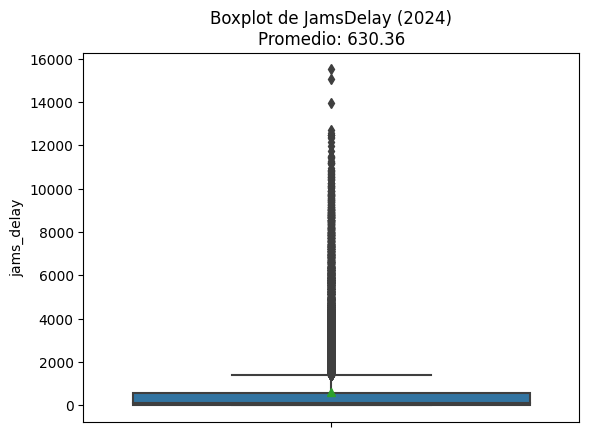

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
sns.boxplot(data=merged, y='jams_delay', showmeans=True)
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()




Text(0.5, 1.0, 'Histograma \ncity_gdp_capita')

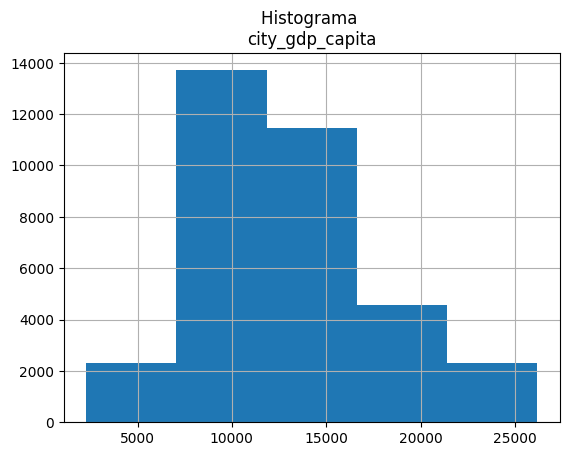

In [18]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)

merged['city_gdp_capita'].hist(bins=5)
plt.title(f'Histograma \ncity_gdp_capita')



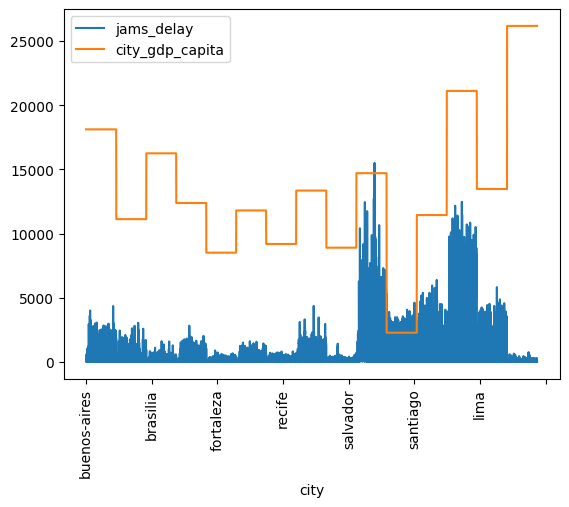

In [21]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot( x="city", y=['jams_delay', 'city_gdp_capita'])
plt.xticks(rotation=90)
plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios:


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---
    
# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
Interpretación
## **Las correlaciones son positivas pero débiles.**

Esto significa que las ciudades con mayor PIB per cápita tienden ligeramente a tener más congestión, pero la relación no es fuerte.

## **Explicación económica del fenómeno**

Existen dos fuerzas opuestas que explican esta relación:

## **A. Más actividad económica → más congestión**

Las ciudades con mayor productividad suelen tener:

Mayor densidad de empleo

Más desplazamientos laborales

Mayor actividad comercial

Mayor uso de infraestructura vial

### **Esto genera:**

PIB alto → más movilidad → mayor congestión

Ejemplo típico: grandes capitales o hubs financieros.
# **En resumen**
la relación entre movilidad urbana y PIB per cápita es positiva pero débil en los datos analizados. Las ciudades con mayor actividad económica tienden a generar más desplazamientos y congestión; sin embargo, cuando la congestión es excesiva puede afectar negativamente la productividad al aumentar los costos de transporte y reducir la eficiencia laboral.

# **Variables utilizadas para la toma de desisiones**

## 1. PIB per cápita (GDP per capita)

Qué mide:
Representa el valor de la producción económica de una ciudad o país dividido entre su población.

## 2. Congestión del tráfico (Traffic congestion / delay)

Qué mide:
El nivel de saturación de las vías urbanas, generalmente expresado como porcentaje de congestión o retraso adicional respecto a un tráfico fluido.

## 3. Tiempo de viaje (Travel time)

Qué mide:
La cantidad de minutos necesarios para recorrer una distancia estándar dentro de la ciudad.

## 4. Minutos de retraso (Minutes of delay)

## Qué mide:
El tiempo adicional que las personas pierden debido al tráfico en comparación con condiciones de tránsito fluido.

## Resumiendo
Estas variables permiten analizar cómo la eficiencia del sistema de movilidad urbana impacta en la productividad económica. Para los responsables de políticas públicas y planificación urbana, comprender estos indicadores facilita la toma de decisiones sobre infraestructura, transporte público y estrategias de reducción de congestión, con el objetivo de mejorar la competitividad y la calidad de vida en las ciudades.

# **Cobertura de datos:**  
## **Resumen del alcance del análisis**

**Indicador	         Valor**
Año analizado	      2024
Número de ciudades	   15
Número de países	    7
Región          	América Latina

# **Metodología (alto nivel):**  

- se cambiaron formatos que al cargar el archivo parececian como **object** a un formato mas apropiado en su mayoria **datetime**

- se  realizo un merge fijado en las celdas city y year para ver la coorelacion de  los embotellamientos con el aumento o disminucion del PIB
# Observación de Graficos

## **1. Distribución de los valores**

El gráfico permite observar la distribución general de ambas variables a lo largo de las ciudades analizadas.

**jams_delay (azul)**: presenta una distribución muy variable, con valores que van desde niveles bajos hasta picos superiores a 10 000–15 000 unidades.

**city_gdp_capita (naranja)**: muestra una variación más estructurada, con niveles que oscilan aproximadamente entre 9 000 y 26 000.

**Validación obtenida:**
La congestión tiene mayor dispersión, mientras que el PIB per cápita presenta una distribución más estable entre ciudades.

## **2. Identificación de outliers**

En la serie de jams_delay se observan picos muy pronunciados en algunas ciudades.

**Interpretación:**

Estas observaciones pueden representar ciudades con congestión excepcionalmente alta.

También sirven para validar que no existan errores de captura, ya que los valores extremos pueden influir en el análisis estadístico.

**Validación obtenida:**
Se detectan posibles outliers en congestión, que indican casos de tráfico significativamente más severo.

## **3. Tendencias generales entre variables**

Al observar ambas series en el mismo gráfico se pueden evaluar patrones generales de comportamiento.

**Observación:**

Algunas ciudades con mayor PIB per cápita coinciden con niveles más altos de congestión.

Sin embargo, la relación no es uniforme, ya que también existen ciudades con PIB alto y congestión moderada.

**Validación obtenida:**
Se sugiere una relación positiva débil entre actividad económica y congestión, lo cual es común en ciudades con alta densidad económica.




# **Hallazgos iniciales:**  

## **Mayor variabilidad en los índices de tráfico**
La variable jams_delay presenta mucha más dispersión que el PIB per cápita. Mientras que el PIB muestra cambios graduales entre ciudades, la congestión presenta fluctuaciones abruptas, lo que indica que factores como infraestructura vial, transporte público o planificación urbana influyen significativamente.


## Outliners


### **Picos extremos en congestión (jams_delay)**
Se observan algunos valores muy elevados en el índice de congestión que superan claramente al resto de las ciudades. Estos picos podrían indicar:

Ciudades con infraestructura vial insuficiente

Problemas estructurales de movilidad

Posibles eventos extraordinarios en los datos

O errores de registro

### **Diferencias marcadas entre ciudades con PIB similar**
Hay ciudades con niveles similares de PIB per cápita, pero con niveles de congestión muy distintos. Esto podría estar relacionado con:

Diferencias en políticas de transporte público

Distintos niveles de planificación urbana

Variaciones en densidad poblacional

### **Posible caso de ciudad con alto PIB y baja congestión**
Si una ciudad muestra alto PIB pero congestión baja, podría representar un caso de eficiencia urbana, lo que sería interesante analizar con mayor profundidad para identificar buenas prácticas.



**Recomendaciones**  

Desde una perspectiva de análisis de datos aplicado a política urbana, la prioridad se determina observando dos condiciones simultáneas:

**Altos niveles de congestión vehicular (jams_delay elevado)**

**PIB per cápita relativamente bajo o medio**

Cuando estas dos variables coinciden, la congestión puede estar limitando la productividad económica, lo que sugiere una oportunidad clara de inversión en infraestructura de transporte.

**Ciudad prioritaria identificada**
**Bogotá (Colombia)**

El análisis muestra que Bogotá es la ciudad donde se observa la relación más evidente entre alta congestión y menor productividad relativa, en comparación con otras ciudades analizadas.

**Razones principales:**

**1. Congestión muy alta**

Bogotá se ubica entre las ciudades con mayor índice de congestión del dataset.

Presenta picos elevados en jams_delay, indicando tiempos de viaje prolongados.

**2. PIB per cápita moderado**

Aunque es un centro económico importante, su PIB per cápita es menor comparado con ciudades como Buenos Aires o Santiago.

**3. Impacto potencial en productividad**

Los tiempos de traslado prolongados afectan:

eficiencia laboral

costos logísticos

movilidad de la fuerza de trabajo

Esto sugiere que mejoras en infraestructura de transporte podrían tener un impacto significativo en la productividad urbana.

# **Conclusiones**
## **1. Priorizar inversión en movilidad en Bogotá**

### **Posibles intervenciones:**

expansión de sistemas de transporte masivo

corredores BRT o metro

infraestructura para movilidad multimodal

Esto podría reducir:

tiempos de traslado

costos logísticos

pérdida de productividad.

El análisis sugiere que Bogotá presenta la mayor combinación de congestión vehicular alta y productividad económica relativamente menor, lo que la convierte en la ciudad prioritaria para inversión en infraestructura de transporte dentro del conjunto analizado. Mejorar la movilidad urbana en esta ciudad podría generar beneficios económicos significativos en términos de eficiencia laboral y competitividad urbana. 📊
